# FEATURE RELATIONSHIPS

# 1. Correlation Matrix

## Definition

A correlation matrix shows the correlation between multiple numerical features in a dataset.

Correlation values range from -1 to +1:

- +1 → Strong positive relationship
- 0 → No relationship
- -1 → Strong negative relationship

## Formula

Correlation = Covariance(X, Y) / (Standard Deviation of X × Standard Deviation of Y)

## Example

If Study Hours and Marks have a correlation of 0.95, it means students who study more hours generally get higher marks.

## Business Example

A company can check the relationship between:

- Advertising Spend
- Sales
- Website Visits
- Customer Orders

## AI/ML Example

Correlation can help identify which features may have a relationship with the target variable.

## Interpretation

A high positive or negative correlation indicates a strong relationship between two variables.

In [1]:
!mamba install seaborn

mambajs 0.21.4

Specs: xeus-python, numpy, matplotlib, pillow, ipywidgets>=8.1.6, ipyleaflet, scipy, seaborn
Channels: emscripten-forge-4x, conda-forge

Solving environment...
Solving took 3.436 seconds
  Name           Version  Build                Channel
--------------------------------------------------------------------
+ pandas         3.0.6    np23py313h124dbc7_0  emscripten-forge-4x
+ patsy          1.0.3    py313h1804a44_0      emscripten-forge-4x
+ python-tzdata  2026.5   pyh5ded981_0         conda-forge
+ seaborn        0.13.2   hd8ed1ab_3           conda-forge
+ seaborn-base   0.13.2   pyhd8ed1ab_3         conda-forge
+ statsmodels    0.14.6   np23py313hd8db738_2  emscripten-forge-4x
- pip            26.2.1   pyh145f28c_0         conda-forge


             Study_Hours  Marks  Sleep_Hours
Study_Hours          1.0    1.0         -1.0
Marks                1.0    1.0         -1.0
Sleep_Hours         -1.0   -1.0          1.0


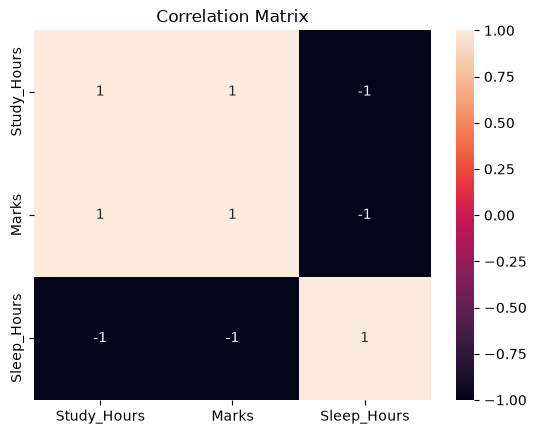

In [2]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

data = {
    "Study_Hours": [1, 2, 3, 4, 5],
    "Marks": [20, 40, 60, 80, 100],
    "Sleep_Hours": [8, 7, 6, 5, 4]
}

df = pd.DataFrame(data)

correlation_matrix = df.corr()

print(correlation_matrix)

sns.heatmap(correlation_matrix, annot=True)
plt.title("Correlation Matrix")
plt.show()

## Code Implementation Explanation

- `df.corr()` calculates the correlation between numerical columns.
- `sns.heatmap()` displays the correlations visually.
- `annot=True` displays the correlation values inside the heatmap.

The heatmap helps us quickly identify strong positive and negative relationships.

# 2. Multicollinearity

## Definition

Multicollinearity occurs when two or more independent features are highly related to each other.

## Example

Suppose a dataset contains:

- Age
- Year_of_Birth

These two features contain almost the same information.

This can create multicollinearity.

## Business Example

A company may have both:

- Monthly Revenue
- Annual Revenue

These features are highly related.

## AI/ML Example

In Linear Regression, highly correlated input features can make the model coefficients unstable.

## Interpretation

High multicollinearity means some features provide very similar information.

We can detect it using correlation or VIF.

In [4]:
import pandas as pd

data = {
    "Age": [20, 25, 30, 35, 40],
    "Year_of_Birth": [2006, 2001, 1996, 1991, 1986],
    "Salary": [25000, 30000, 40000, 50000, 60000]
}

df = pd.DataFrame(data)

print(df.corr())

                    Age  Year_of_Birth    Salary
Age            1.000000      -1.000000  0.993884
Year_of_Birth -1.000000       1.000000 -0.993884
Salary         0.993884      -0.993884  1.000000


## Interpretation

Age and Year_of_Birth have a strong negative correlation.

This means they provide very similar information.

Keeping both features in some ML models may create multicollinearity.

# 3. VIF – Variance Inflation Factor

## Definition

VIF is a statistical measure used to detect multicollinearity between features.

A higher VIF indicates stronger multicollinearity.

## General Interpretation

- VIF = 1 → No multicollinearity
- VIF between 1 and 5 → Usually acceptable
- VIF > 5 → Possible multicollinearity
- VIF > 10 → High multicollinearity

## Formula

VIF = 1 / (1 - R²)

## Business Example

If Revenue and Monthly Sales have a very high VIF, they may contain similar information.

## AI/ML Example

VIF can be used before Linear Regression to identify features that are highly related to other input features.

## Interpretation

VIF helps us decide whether some features should be removed from a model.

In [5]:
import pandas as pd
from statsmodels.stats.outliers_influence import variance_inflation_factor

data = {
    "Study_Hours": [1, 2, 3, 4, 5],
    "Practice_Hours": [2, 4, 6, 8, 10],
    "Sleep_Hours": [8, 7, 6, 5, 4]
}

df = pd.DataFrame(data)

vif_data = pd.DataFrame()

vif_data["Feature"] = df.columns

vif_data["VIF"] = [
    variance_inflation_factor(df.values, i)
    for i in range(df.shape[1])
]

print(vif_data)

          Feature       VIF
0     Study_Hours       inf
1  Practice_Hours       inf
2     Sleep_Hours  2.580247


## Code Implementation Explanation

- `variance_inflation_factor()` calculates the VIF value.
- Each feature gets a VIF score.
- A high VIF indicates that a feature is strongly related to other features.

If `statsmodels` is not installed, run:

%pip install statsmodels

# 4. Feature Importance

## Definition

Feature importance tells us how useful each feature is for making predictions.

Some features contribute more to the prediction than others.

## Example

For predicting house prices:

- House Size
- Number of Bedrooms
- Location
- Age of House

House Size may be more important than the number of bedrooms.

## Business Example

A company can identify which factors have the biggest effect on customer churn.

## AI/ML Example

Tree-based models such as Decision Trees and Random Forests can calculate feature importance.

## Interpretation

A higher feature importance means the feature contributed more to the model's predictions.

In [7]:
!mamba install scikit-learn

mambajs 0.21.4

Specs: xeus-python, numpy, matplotlib, pillow, ipywidgets>=8.1.6, ipyleaflet, scipy, seaborn, scikit-learn
Channels: emscripten-forge-4x, conda-forge

Solving environment...
Solving took 1.225 seconds
  Name                Version    Build                Channel
---------------------------------------------------------------------------
+ brotli-python       1.2.0      py313ha26e73d_2      emscripten-forge-4x
+ certifi             2026.7.22  pyhd8ed1ab_0         conda-forge
+ charset-normalizer  3.5.1      pyhd8ed1ab_0         conda-forge
+ idna                3.20       pyh5ded981_0         conda-forge
+ joblib              1.6.0      py313h57e9779_0      emscripten-forge-4x
+ narwhals            2.27.0     pyh5ded981_0         conda-forge
+ pysocks             1.7.1      py313h1804a44_3      emscripten-forge-4x
+ requests            2.34.2     pyhcf101f3_0         conda-forge
+ scikit-learn        1.9.0      np23py313hb9816c2_0  emscripten-forge-4x
+ setuptools       

In [8]:
from sklearn.tree import DecisionTreeRegressor
import pandas as pd

data = {
    "Study_Hours": [1, 2, 3, 4, 5, 6],
    "Sleep_Hours": [8, 7, 8, 6, 7, 6],
    "Practice_Hours": [1, 2, 2, 4, 4, 5],
    "Marks": [35, 45, 55, 70, 80, 90]
}

df = pd.DataFrame(data)

X = df[["Study_Hours", "Sleep_Hours", "Practice_Hours"]]
y = df["Marks"]

model = DecisionTreeRegressor(random_state=42)

model.fit(X, y)

importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": model.feature_importances_
})

print(importance)

          Feature  Importance
0     Study_Hours    0.067039
1     Sleep_Hours    0.044693
2  Practice_Hours    0.888268


## Code Implementation Explanation

- `X` contains the input features.
- `y` contains the target variable.
- `DecisionTreeRegressor` creates a regression model.
- `feature_importances_` calculates the importance of each feature.
- Higher values indicate more important features.

## Interpretation

The output shows which features are contributing more to predicting Marks.

# 5. Feature Selection Basics

## Definition

Feature selection is the process of selecting the most useful features and removing unnecessary features.

## Why Feature Selection?

Feature selection can:

- Reduce unnecessary data
- Make models simpler
- Reduce training time
- Reduce overfitting
- Improve model performance

## Example

Suppose we have 20 features but only 5 are useful for prediction.

We can select the 5 useful features and remove the remaining features.

## Business Example

For customer churn prediction, useful features may include:

- Customer Age
- Monthly Charges
- Contract Type
- Customer Tenure

Unnecessary features can be removed.

## AI/ML Example

Feature selection is commonly used before training ML models.

## Interpretation

Good feature selection helps the model focus on the most useful information.

In [9]:
from sklearn.feature_selection import SelectKBest, f_regression
import pandas as pd

data = {
    "Study_Hours": [1, 2, 3, 4, 5, 6],
    "Sleep_Hours": [8, 7, 8, 6, 7, 6],
    "Practice_Hours": [1, 2, 2, 4, 4, 5],
    "Marks": [35, 45, 55, 70, 80, 90]
}

df = pd.DataFrame(data)

X = df[["Study_Hours", "Sleep_Hours", "Practice_Hours"]]
y = df["Marks"]

selector = SelectKBest(score_func=f_regression, k=2)

X_selected = selector.fit_transform(X, y)

selected_features = X.columns[selector.get_support()]

print("Selected Features:")
print(selected_features)

print("\nSelected Data:")
print(X_selected)

Selected Features:
Index(['Study_Hours', 'Practice_Hours'], dtype='str')

Selected Data:
[[1 1]
 [2 2]
 [3 2]
 [4 4]
 [5 4]
 [6 5]]


## Code Implementation Explanation

- `SelectKBest` selects the best features based on statistical scores.
- `f_regression` is used for a regression problem.
- `k=2` means we want to select the best 2 features.
- `get_support()` identifies which features were selected.

## Interpretation

The selected features are the features that have the strongest statistical relationship with the target variable.

Feature selection helps create a simpler and more efficient ML model.